In [250]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from fontTools.diff import color
from matplotlib import figure
from datetime import datetime, timedelta

from scipy.cluster.hierarchy import centroid
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [251]:
df = pd.read_csv("../data/main_data.csv")

# Clleaning data & formating it

In [252]:
df = df.dropna(subset=["CustomerID"]).copy()

df["CustomerID"] = df["CustomerID"].astype(int)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()
df["UnitPrice"] = pd.to_numeric(
    df["UnitPrice"].astype(str).str.replace(",", ".", regex=False),
    errors="raise",
)

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df.drop_duplicates()

df.info()

/tmp/ipykernel_54132/3062030550.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"]).dt.normalize()


<class 'pandas.DataFrame'>
Index: 392691 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    392691 non-null  str           
 1   StockCode    392691 non-null  str           
 2   Description  392691 non-null  str           
 3   Quantity     392691 non-null  int64         
 4   InvoiceDate  392691 non-null  datetime64[us]
 5   UnitPrice    392691 non-null  float64       
 6   CustomerID   392691 non-null  int64         
 7   Country      392691 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 27.0 MB


In [253]:
nominal = df[["InvoiceDate", "StockCode", "Description","CustomerID", "Country"]]
ordinal = df[["InvoiceDate"]]
discrete = df[["Quantity"]]
continuous = df[["UnitPrice"]]

# Data visualization

### Customers per country

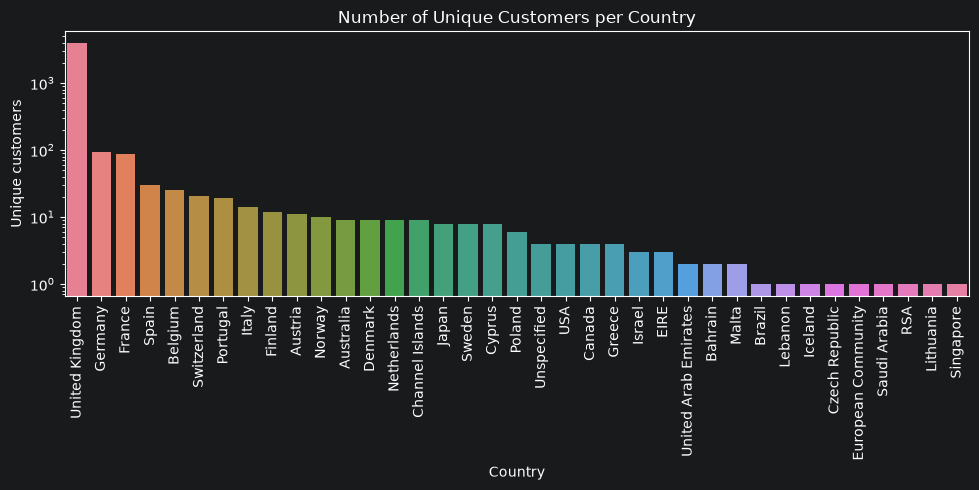

In [254]:
cust_per_country = (
    df.groupby("Country")["CustomerID"]
      .nunique()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=cust_per_country.index, y=cust_per_country.values,
            hue=cust_per_country.index, legend=False)
plt.title("Number of Unique Customers per Country")
plt.ylabel("Unique customers")
plt.xlabel("Country")
plt.xticks(rotation=90)
plt.tight_layout()
plt.yscale("log")
plt.show()

### Sales per countery

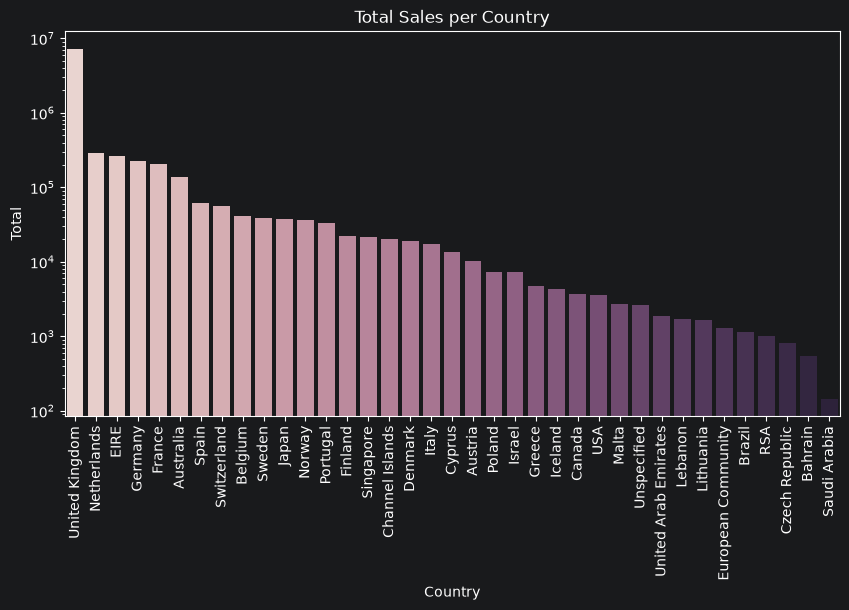

In [255]:
df["Total"] = df["Quantity"] * df["UnitPrice"]

data = (
    df.groupby("Country")["Total"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=data, x="Country", y="Total", hue=data.index, legend=False)
plt.xticks(rotation=90)
plt.title("Total Sales per Country")
plt.yscale("log")
plt.show()

# RFM

In [256]:
CRFM = pd.DataFrame(df["CustomerID"].unique(), columns=["CustomerID"])

### Monetary

In [257]:
CRFM = df.groupby("CustomerID")["Total"].sum().rename("Monetary").reset_index()
CRFM

,CustomerID,Monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40
...,...,...
4333,18280,180.60
4334,18281,80.82
4335,18282,178.05
4336,18283,2045.53


### Recency

In [258]:
last_sale = df.groupby("CustomerID")["InvoiceDate"].max()
CRFM["LastSale"] = CRFM["CustomerID"].map(last_sale)

snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)
CRFM["Recency"] = (snapshot - CRFM["LastSale"]).dt.days
CRFM.drop(columns=["LastSale"], inplace=True)
CRFM

,CustomerID,Monetary,Recency
0,12346,77183.60,326
1,12347,4310.00,3
2,12348,1797.24,76
3,12349,1757.55,19
4,12350,334.40,311
...,...,...,...
4333,18280,180.60,278
4334,18281,80.82,181
4335,18282,178.05,8
4336,18283,2045.53,4


### Frequency

In [259]:
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()
CRFM["Frequency"] = CRFM["CustomerID"].map(frequency)
CRFM

,CustomerID,Monetary,Recency,Frequency
0,12346,77183.60,326,1
1,12347,4310.00,3,7
2,12348,1797.24,76,4
3,12349,1757.55,19,1
4,12350,334.40,311,1
...,...,...,...,...
4333,18280,180.60,278,1
4334,18281,80.82,181,1
4335,18282,178.05,8,2
4336,18283,2045.53,4,16


# RFM Visualization

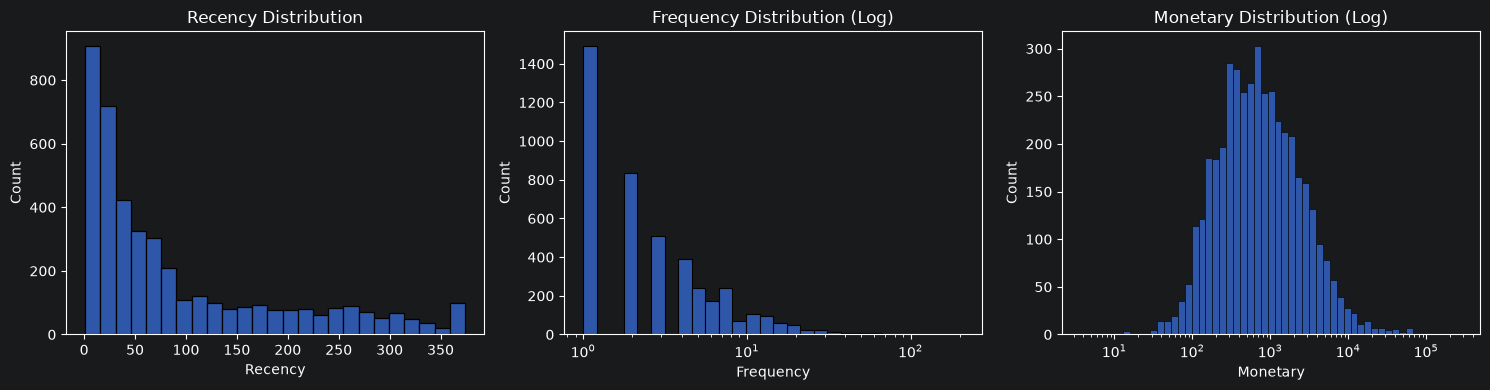

In [260]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

sns.histplot(CRFM["Recency"], ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(CRFM["Frequency"], ax=axes[1], log_scale=True)
axes[1].set_title("Frequency Distribution (Log)")

sns.histplot(CRFM["Monetary"], ax=axes[2], log_scale=True)
axes[2].set_title("Monetary Distribution (Log)")

plt.tight_layout()
plt.show()

# Normalisation

In [261]:
# RFM = (CRFM[["Recency", "Frequency", "Monetary"]] - CRFM[["Recency", "Frequency", "Monetary"]].min()) / (CRFM[["Recency", "Frequency", "Monetary"]].max() - CRFM[["Recency", "Frequency", "Monetary"]].min())
# CRFM

# Standariwation

In [262]:
RFM = CRFM[["Monetary", "Frequency", "Recency"]].copy()

RFM["Monetary"] = np.log1p(RFM["Monetary"])
RFM["Frequency"] = np.log1p(RFM["Frequency"])
RFM["Recency"] = np.log1p(RFM["Recency"])

In [263]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

RFM = scaler.fit_transform(
    RFM
)
RFM = pd.DataFrame(
    RFM,
    columns=["Monetary", "Frequency", "Recency"]
)

# K-means

## Elbow method

In [264]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, pairwise_distances_argmin_min
from scipy.spatial.distance import cdist
import numpy as np

In [265]:
inertias = []
mapping = {}
K = range(1, 20)

for k in K:
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(RFM)

    inertias.append(kmeanModel.inertia_)

    mapping[k] = inertias[-1]

Inertia values:
1 : 13014.000000000004
2 : 6476.523148341361
3 : 4858.666591819131
4 : 3925.425549572674
5 : 3271.9284474413494
6 : 2852.9970341738062
7 : 2540.281649785781
8 : 2345.91356773933
9 : 2171.2732225014634
10 : 1989.4047090832662
11 : 1861.0425963926257
12 : 1757.7978859667649
13 : 1673.3177197744008
14 : 1609.8043823701883
15 : 1503.235121812758
16 : 1471.5248695053795
17 : 1397.777110782214
18 : 1348.0011091480155
19 : 1315.6040789379003


/tmp/ipykernel_54132/1136457268.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(K, inertias, "bx-",color="red")


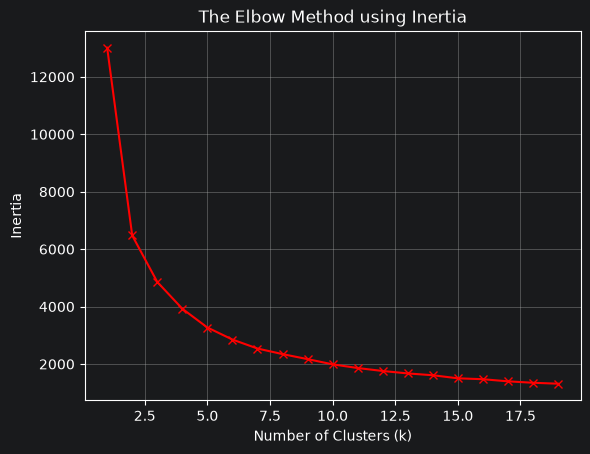

In [266]:
print("Inertia values:")
for key, val in mapping.items():
    print(f'{key} : {val}')

plt.plot(K, inertias, "bx-",color="red")
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method using Inertia')
plt.grid()
plt.show()

### Elbow curve analysis
From the above graph, we can deduce that the best k-means sits between 3 <= k >= 7

## Silouhette score

In [267]:
valid_K = range(2,11)
scors = {}
for k in valid_K:
    kmeanModel = KMeans(n_clusters=k, random_state=42, n_init=10)
    predicted_labels = kmeanModel.fit_predict(RFM)
    scors[k] = silhouette_score(RFM, predicted_labels)

In [268]:
for s in scors:
    print(f"Silhouette score for {s} clusters: {scors[s]}")

Silhouette score for 2 clusters: 0.4325090750300475
Silhouette score for 3 clusters: 0.3362880622386299
Silhouette score for 4 clusters: 0.33290208100066715
Silhouette score for 5 clusters: 0.3180779576712943
Silhouette score for 6 clusters: 0.31287256269668484
Silhouette score for 7 clusters: 0.3102960103848029
Silhouette score for 8 clusters: 0.30206236460749414
Silhouette score for 9 clusters: 0.296020590493119
Silhouette score for 10 clusters: 0.2770785147230721


/tmp/ipykernel_54132/1851402264.py:2: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "rx-" (-> color='r'). The keyword argument will take precedence.
  plt.plot(list(scors.keys()), list(scors.values()), "rx-", c="y")


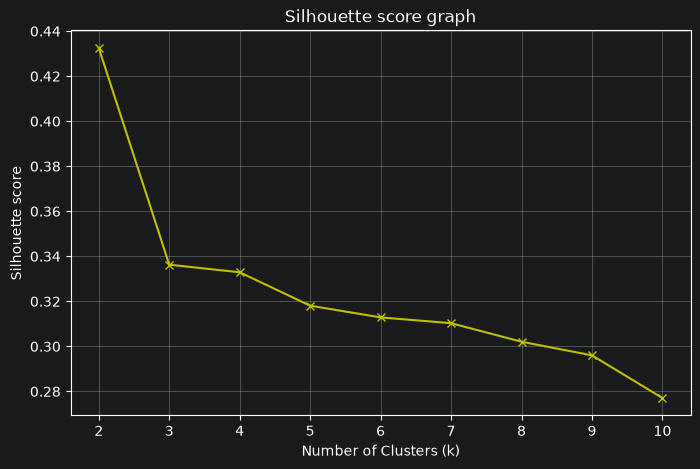

In [269]:
plt.figure(figsize=(8, 5))
plt.plot(list(scors.keys()), list(scors.values()), "rx-", c="y")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette score graph")
plt.xticks(list(scors.keys()))
plt.grid()
plt.show()

### Silouhette score analysis
We guessed before that 3 <= k >= 7, but for testing pourpuses, we calculeted the score of (2,11).
The results was close enough to our previous guess, the best score belonged to k = 2 with a score of 0.722

### Difference between the best k (2) and the demanded one (3)
Although 2 was shown to be the best k, 3 would allow an Ecomerce buiseness which our data is from to handdle a more diverse pool of clients, as categorizing people to 3 groups with a right middle left mentality gives more options to make strategies to capture them than a plain either 1 or 2

In [270]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
rfmPCA = pca.fit_transform(RFM)
KModel = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = KModel.fit_predict(RFM)

CRFM["Cluster"] = labels
rfmPCA

array([[ 0.86441819,  2.70279034],
       [ 2.47639368, -0.6766027 ],
       [ 0.47749699,  0.74722246],
       ...,
       [-0.23697423, -1.68345437],
       [ 2.71744298, -0.51302878],
       [ 0.50545719,  0.30576252]], shape=(4338, 2))

In [271]:
# from sklearn.metrics.pairwise import pairwise_distances_argmin_min
# closest, test = pairwise_distances_argmin_min(KModel.cluster_centers_, rfm)
# test

# Cluster visualization

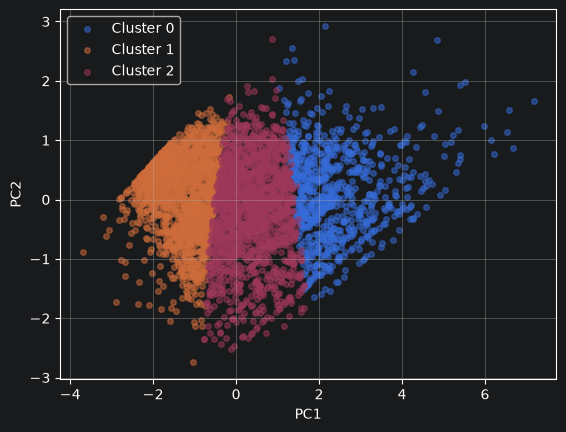

In [272]:
u_labels = np.unique(labels)
for i in u_labels:
    plt.scatter(rfmPCA[labels == i , 0] , rfmPCA[labels == i , 1] , label = f"Cluster {i}", alpha=0.5, s=16)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid()
plt.show()

# Cluster centroids

In [273]:
centroid = KModel.cluster_centers_
centroid = scaler.inverse_transform(centroid)
centroid = np.expm1(centroid)
centroid

array([[4.26867747e+03, 1.06951970e+01, 1.02243000e+01],
       [2.73402389e+02, 1.28816265e+00, 1.30141859e+02],
       [9.40788448e+02, 3.07462058e+00, 2.88753560e+01]])

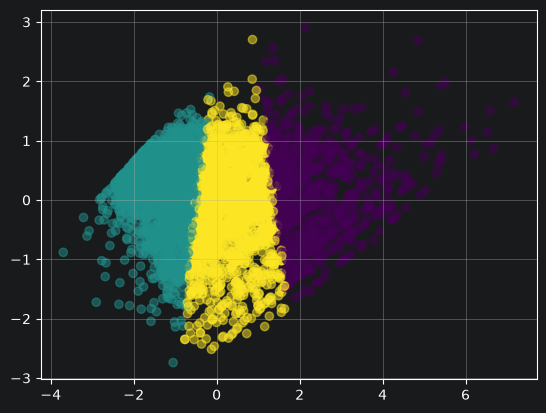

In [274]:
plt.scatter(
    rfmPCA[:,0],
    rfmPCA[:, 1],
    c=CRFM["Cluster"],
    alpha=0.5
)

plt.grid(True)
plt.show()

## RFM Cluster Profiling

In [275]:
stats = CRFM.groupby("Cluster").agg(
    number_of_customers=("Cluster", "size"),
    avg_recency=("Recency", "mean"),
    median_recency=("Recency", "median"),
    avg_frequency=("Frequency", "mean"),
    median_frequency=("Frequency", "median"),
    avg_monetary=("Monetary", "mean"),
    median_monetary=("Monetary", "median"),
    total_revenue=("Monetary", "sum"),
).round(2)
stats.columns = pd.MultiIndex.from_tuples([
    ("Customers", "count"),
    ("Recency", "mean"), ("Recency", "median"),
    ("Frequency", "mean"), ("Frequency", "median"),
    ("Monetary", "mean"), ("Monetary", "median"), ("Monetary", "sum"),
])
stats

Customers Recency        Frequency        Monetary           \
            count    mean median      mean median     mean   median   
Cluster                                                               
0             775   17.97   10.0     13.31   10.0  7879.99  3701.44   
1            1866  168.87  160.0      1.36    1.0   362.51   296.09   
2            1697   43.99   30.0      3.35    3.0  1239.70   962.19   

                     
                sum  
Cluster              
0        6106993.09  
1         676449.08  
2        2103762.82

In [276]:
stats.insert(0, "cluster_name", ["Loyal", "Lost", "Casual"])

In [277]:
stats = stats.reindex([0,2,1])
stats

cluster_name Customers Recency        Frequency        Monetary  \
                         count    mean median      mean median     mean   
Cluster                                                                   
0              Loyal       775   17.97   10.0     13.31   10.0  7879.99   
2             Casual      1697   43.99   30.0      3.35    3.0  1239.70   
1               Lost      1866  168.87  160.0      1.36    1.0   362.51   

                              
          median         sum  
Cluster                       
0        3701.44  6106993.09  
2         962.19  2103762.82  
1         296.09   676449.08

## Clusters observation
From the statistics above, we can easelly see that the 3 clusters are split into:

**Loyal:** Most cutomers, with the lowest recency score, and the highest frequency and monetary gains.

**Lost:** Customers who didn't buy in a long time, who also have the lowest frequency and monetary gains.

**Casual:** these are customers who sit in between, who have practically 2x better scores than the Lost group, with a frequency and monetary gain sitting right in the middle.

In [278]:

# import matplotlib.pyplot as plt
# import numpy as np
# from sklearn.cluster import DBSCAN
# from sklearn.neighbors import NearestNeighbors
#
# min_samples = 6
# dist, test = NearestNeighbors(n_neighbors=min_samples).fit(RFM).kneighbors(RFM)
# plt.plot(np.sort(dist[:, -1]))
# plt.xlabel("Points (sorted)"); plt.ylabel(f"Distance to {min_samples}th neighbor")
# plt.grid(True)
# plt.show()
# print(test)
#
# db = DBSCAN(eps=0.4, min_samples=min_samples).fit(RFM)
# labels = db.labels_
#
# coords = PCA(n_components=2).fit_transform(RFM)
# for lab in sorted(set(labels)):
#     m = labels == lab
#     if lab == -1:
#         plt.scatter(coords[m, 0], coords[m, 1], c="k", marker="x", s=15, label="Noise")
#     else:
#         plt.scatter(coords[m, 0], coords[m, 1], s=15, alpha=0.6, label=f"Cluster {lab}")
# plt.title(f"DBSCAN: 3 clusters")
# plt.legend()
# plt.grid(True)
# plt.show()
#
# mask = labels != -1


In [279]:
# from sklearn.metrics import calinski_harabasz_score
#
# ch_scores = {}
# for k in range(2, 11):
#     labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(RFM)
#     ch_scores[k] = calinski_harabasz_score(RFM, labels)
#
# plt.plot(list(ch_scores.keys()), list(ch_scores.values()), "go-")
# plt.xlabel("Number of Clusters (k)")
# plt.ylabel("Calinski-Harabasz score")
# plt.grid()
# plt.show()

In [280]:
# from sklearn.metrics import davies_bouldin_score
#
# db_scores = {}
# for k in range(2, 11):
#     labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(RFM)
#     db_scores[k] = davies_bouldin_score(RFM, labels)
#
# plt.plot(list(db_scores.keys()), list(db_scores.values()), "mo-")
# plt.xlabel("Number of Clusters (k)")
# plt.ylabel("Davies-Bouldin score")
# plt.grid()
# plt.show()

In [281]:
CRFM['Cluster_name'] = CRFM['Cluster'].map({0: "Loyal", 1: "Lost", 2: "Casual"})
CRFM

,CustomerID,Monetary,Recency,Frequency,Cluster,Cluster_name
0,12346,77183.60,326,1,2,Casual
1,12347,4310.00,3,7,0,Loyal
2,12348,1797.24,76,4,2,Casual
3,12349,1757.55,19,1,2,Casual
4,12350,334.40,311,1,1,Lost
...,...,...,...,...,...,...
4333,18280,180.60,278,1,1,Lost
4334,18281,80.82,181,1,1,Lost
4335,18282,178.05,8,2,2,Casual
4336,18283,2045.53,4,16,0,Loyal


# Random Forrest Clustering

In [287]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(RFM[["Monetary", "Frequency", "Recency"]], CRFM['Cluster'], test_size=0.2, random_state=42, stratify=CRFM['Cluster'])

Forest = RandomForestClassifier(max_depth=3, random_state=42, n_estimators=50)
Forest.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: 

## Evaluation

In [288]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
Forest = RandomForestClassifier(max_depth=3, random_state=42, n_estimators=50)

scoring = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]
results = cross_validate(Forest, x_train, y_train, cv=skf, scoring=scoring)

for metric in scoring:
    scores = results[f"test_{metric}"]
    print(f"{metric}: {scores.mean():.3f}, std: {scores.std():.3f}  (per fold: {scores.round(3)})")


accuracy: 0.931, std: 0.009  (per fold: [0.941 0.919 0.922 0.937 0.937])
precision_macro: 0.943, std: 0.011  (per fold: [0.954 0.924 0.939 0.948 0.952])
recall_macro: 0.917, std: 0.011  (per fold: [0.917 0.904 0.905 0.931 0.929])
f1_macro: 0.928, std: 0.010  (per fold: [0.932 0.913 0.919 0.938 0.937])


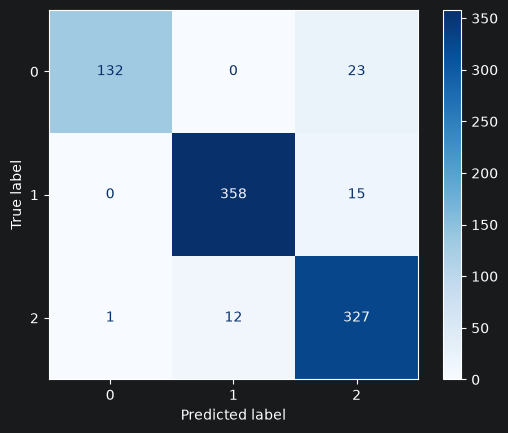

In [289]:
from sklearn.metrics import ConfusionMatrixDisplay
Forest.fit(x_train, y_train)
prediction = Forest.predict(x_test)
ConfusionMatrixDisplay.from_predictions(y_test, prediction, cmap="Blues")
plt.show()

## Analysis
RandomForestClassifier, after calculating it's scores; We can see that the score for each metric are hight and the std is very low, which indicated proper fitting of the model.
The confusion matrix confirms this as the model, even though there are some mistakes, it predicts most of the clients class corectly.

# Feature importance

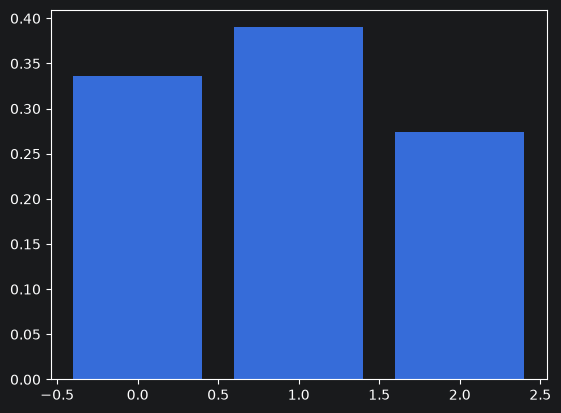

In [290]:
importance = Forest.feature_importances_
print()
plt.bar([x for x in range(len(importance))], importance)
plt.show()

## Importance analysis
feature 2 which is recency, results in the least impurity, followed by monetary then frequency, which means our forest model, relies on the recency value a costumer hase more than the other 2 features.

# Testing with new data

In [293]:
test_clients = pd.DataFrame({
    "Monetary":  [12500, 4800, 25000,  150,   90,  320,  700, 1500,  2200,  600],
    "Frequency": [   30,   15,    45,    1,    1,    2,    3,    4,     6,    2],
    "Recency":   [    5,   12,     3,  340,  290,  250,   60,   95,    45,  150],
}, index=[f"client_{i}" for i in range(1, 11)])

features = ["Monetary", "Frequency", "Recency"]

test_log = np.log1p(test_clients[features])

test_scaled = pd.DataFrame(
    scaler.transform(test_log),
    columns=features,
    index=test_clients.index,
)

result = test_clients[features].copy()
result["Predicted"] = Forest.predict(test_scaled)
result["Label"] = result["Predicted"].map({0: "Loyal", 1: "Lost", 2: "Casual"})
print(result)

           Monetary  Frequency  Recency  Predicted   Label
client_1      12500         30        5          0   Loyal
client_2       4800         15       12          0   Loyal
client_3      25000         45        3          0   Loyal
client_4        150          1      340          1    Lost
client_5         90          1      290          1    Lost
client_6        320          2      250          1    Lost
client_7        700          3       60          2  Casual
client_8       1500          4       95          2  Casual
client_9       2200          6       45          2  Casual
client_10       600          2      150          1    Lost


# Joblib

In [294]:
import joblib

joblib.dump(Forest, "../artifacts/Forest.pkl")

['../artifacts/Forest.pkl']

In [296]:
loaded = joblib.load('../artifacts/Forest.pkl')
loaded.predict(test_scaled)

array([0, 0, 0, 1, 1, 1, 2, 2, 2, 1], dtype=int32)